# 🍔 Prediction of Time for Delivery of Food 

## 📌 Summary of the Project 

Platforms for delivery of food like Swiggy and Zomato are tasked with the job of estimating the time an order would take to reach a customer. 

In this project, I am building a **regression model in **Machine Learning** to evaluate what is the time taken in delivery of food in minutes with the help of such factors like average pace, weather, hour of the day and location in mind. 

### 🎯 Goal of the Project 

> **Is it possible to make predictions of time taken in the delivery of food before making actual delivery?**

The objective is to use past data for deliveries in order to understand the correlation between factors used as input and the time of delivery.

### 🤖 Approach of Machine Learning 

This is a **Supervised Learning→Regression** task because the dependent variable is continuous.

**Input features(X):**
- 🚦 Impact of traffic
- 🌦️ Impact of weather
- 🕐 Hour of the day
- 📍 Location
- Other parameters related to delivery 

**Dependent Variable (y):**
- ⏱️ Time for Delivery

### 🔄 Workflow of the Project 

**Business Problem→Data Collection→Data Understanding→EDA→Data Cleaning→Feature Engineering→Encoding→Model building→Evaluation→Deployment** 

### 🛠️ Technologies Used 

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Successfully Imported")

Successfully Imported


### Importing and Understanding the Dataset

In [100]:
data = pd.read_csv('Food delivery.csv')
data

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [101]:
data.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [102]:
data.tail()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26
45592,0x5fb2,RANCHIRES09DEL02,23,4.9,23.351058,85.325731,23.431058,85.405731,02-03-2022,17:10:00,17:15:00,conditions Fog,Medium,2,Snack,scooter,1,No,Metropolitian,(min) 36


#### Check Nubmer of Rows and columns in the dataset:

In [103]:
data.shape

(45593, 20)

#### Check Datatypes and Null counts:

In [104]:
data.info()

# here every row is non-null.. means the dataset doesn't have any null values 

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [105]:
# here Delivery_person Age is in the form of str and same issue if for delivery person Ratings
print(type(data['Delivery_person_Age'][0]))
print(type(data['Delivery_person_Ratings'][0]))

<class 'str'>
<class 'str'>


In [106]:
data['Weatherconditions']
# here we have to remove conditions from the start 

0             conditions Sunny
1            conditions Stormy
2        conditions Sandstorms
3             conditions Sunny
4            conditions Cloudy
                 ...          
45588         conditions Windy
45589         conditions Windy
45590        conditions Cloudy
45591        conditions Cloudy
45592           conditions Fog
Name: Weatherconditions, Length: 45593, dtype: str

In [107]:
data['Weatherconditions'].value_counts()
# here we have NaN values NaN - represents not a number 

Weatherconditions
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [108]:
data[data['Weatherconditions'] == 'conditions NaN']
# Observation: in road_traafic_density we have NaN values.
# From this also we can say that we have null values.. but these null values are represented in the form of NaN

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
74,0xa9f,BANGRES13DEL01,NaN,NaN,12.935662,77.614130,12.975662,77.654130,11-03-2022,NaN,15:30:00,conditions NaN,NaN,1,Drinks,scooter,0,No,Metropolitian,(min) 19
120,0x6e2,VADRES06DEL01,NaN,NaN,22.312790,73.170283,22.422790,73.280283,02-04-2022,NaN,18:25:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25
250,0x1b50,PUNERES16DEL01,NaN,NaN,18.536718,73.830327,18.646718,73.940327,08-03-2022,NaN,21:25:00,conditions NaN,NaN,3,Buffet,motorcycle,1,Yes,Urban,(min) 43
348,0x4c1,BANGRES13DEL02,NaN,NaN,12.935662,77.614130,13.065662,77.744130,02-03-2022,NaN,00:05:00,conditions NaN,NaN,3,Drinks,scooter,1,No,Metropolitian,(min) 26
425,0xc003,DEHRES13DEL02,NaN,NaN,-30.366322,-78.070453,30.496322,78.200453,18-02-2022,NaN,22:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45332,0x2950,VADRES04DEL02,50,6,0.000000,0.000000,0.020000,0.020000,19-03-2022,NaN,10:40:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Urban,(min) 28
45394,0xdc4,RANCHIRES02DEL03,NaN,NaN,0.000000,0.000000,0.030000,0.030000,05-03-2022,NaN,17:25:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 21
45504,0x461,BANGRES07DEL02,NaN,NaN,-12.978453,-77.643685,12.998453,77.663685,17-03-2022,NaN,09:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,NaN,(min) 24
45518,0x863,INDORES05DEL01,NaN,NaN,22.727021,75.884167,22.737021,75.894167,19-03-2022,NaN,11:40:00,conditions NaN,NaN,3,Snack,electric_scooter,0,No,Metropolitian,(min) 25


#### Data Cleaning

1. Solving the error in Wheater Condtion

In [109]:
data['Weatherconditions'] = data['Weatherconditions'].apply(lambda temp:temp.split(" ")[1] if pd.notnull(temp) else temp)
# this goes throgh the content of each col and makes the value inside it as temp --> then execute and then it goes to 2nd column and goes on

In [110]:
data['Weatherconditions']

0             Sunny
1            Stormy
2        Sandstorms
3             Sunny
4            Cloudy
            ...    
45588         Windy
45589         Windy
45590        Cloudy
45591        Cloudy
45592           Fog
Name: Weatherconditions, Length: 45593, dtype: str

2. Converting objects to string 

In [111]:
data.select_dtypes(include = 'str') # can also use (include = 'object')

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,19-03-2022,11:30:00,11:45:00,Sunny,High,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,25-03-2022,19:45:00,19:50:00,Stormy,Jam,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,05-04-2022,18:00:00,18:10:00,Sunny,Medium,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,26-03-2022,13:30:00,13:45:00,Cloudy,High,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,24-03-2022,11:35:00,11:45:00,Windy,High,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,16-02-2022,19:55:00,20:10:00,Windy,Jam,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,11-03-2022,23:50:00,00:05:00,Cloudy,Low,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,07-03-2022,13:35:00,13:40:00,Cloudy,High,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [112]:
data.select_dtypes(include = 'str').columns

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density',
       'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival',
       'City', 'Time_taken(min)'],
      dtype='str')

3. Removing Leading and Trailing Spaces

In [113]:
for col in data.select_dtypes(include = 'str').columns:
    data[col] = data[col].str.strip() # this will remove all leading and trailing space from the column names
    data[col] = data[col].replace('NaN',np.nan) # this will replace NaN with np.nan
# strip() was did first coz some nan values are stored in the form of ' NaN ' to remove the space we remove strip()

In [114]:
data[data['Delivery_person_Age'] == 'NaN']

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)


In [115]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  str    
 3   Delivery_person_Ratings      43685 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

3. Solve That timetaken(min) issues 

In [116]:
data['Time_taken(min)'] = data['Time_taken(min)'].apply(lambda temp:int(temp.split(" ")[1]) if pd.notnull(temp) else temp)

In [117]:
data['Time_taken(min)']

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 45593, dtype: int64

In [118]:
type(data['Time_taken(min)'][0])

numpy.int64

4. Typecasting Str looking num values to int 

In [119]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  str    
 3   Delivery_person_Ratings      43685 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

In [120]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
    data[col] = pd.to_numeric(data[col],errors = 'coerce') 
# errors = 'coerce' will replace anything other than numeric values with NaN values 
# errors = 'coerce'is importnat coz if we have any missing value it will throw error 

In [121]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

In [122]:
data.describe() # -- this is decriptive stats only applied for numerical columns 

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.633780,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.334716,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


Observation from above:
1. Ratings are from 1 to 5 but here the maximum rating is 6

In [123]:
data[data['Delivery_person_Ratings']>5]['Delivery_person_Ratings']
# here we cant remove this because we'll lose other information, best we can replace it wil 5.0 IMO - we can keep 6 star sa well 

3586     6.0
4714     6.0
5169     6.0
5362     6.0
5651     6.0
6394     6.0
7031     6.0
7681     6.0
9499     6.0
9535     6.0
10100    6.0
10737    6.0
12297    6.0
13257    6.0
13652    6.0
14106    6.0
14907    6.0
14944    6.0
16798    6.0
17145    6.0
17708    6.0
18977    6.0
19382    6.0
20269    6.0
21320    6.0
22416    6.0
23375    6.0
24237    6.0
24918    6.0
25285    6.0
26052    6.0
27221    6.0
27399    6.0
28315    6.0
28974    6.0
29535    6.0
30579    6.0
30943    6.0
31233    6.0
32326    6.0
33533    6.0
34688    6.0
38007    6.0
38020    6.0
38561    6.0
38649    6.0
39699    6.0
40223    6.0
41105    6.0
41969    6.0
42072    6.0
42835    6.0
45332    6.0
Name: Delivery_person_Ratings, dtype: float64

In [124]:
data['Delivery_person_Ratings'] = data['Delivery_person_Ratings'].clip(upper = 5.0)

In [125]:
data.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,43739.000000,43685.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,44600.000000,45593.000000
mean,29.567137,4.632567,17.017729,70.231332,17.465186,70.845702,1.023359,0.744664,26.294607
std,5.815155,0.331560,8.185109,22.883647,7.335122,21.118812,0.839065,0.572473,9.383806
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.933284,73.170000,12.988453,73.280000,0.000000,0.000000,19.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000,1.000000,26.000000
75%,35.000000,4.900000,22.728163,78.044095,22.785049,78.107044,2.000000,1.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


5. Missing Values

In [126]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          43739 non-null  float64
 3   Delivery_person_Ratings      43685 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

There are two ways to fill missing values: 
1. Numeric 
2. Categorical

Numeric column null values is replaced by Median or can 50% 

In [127]:
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
    data[col] = data[col].fillna(data[col].median())

In [128]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            44977 non-null  str    
 12  Road_traffic_density         44992 non-null  str    
 13  Vehicle_condition          

Categorical column is replaced with the mode ie most frequent category

In [129]:
for col in ['Weatherconditions','Road_traffic_density','Festival','City']:
    data[col] = data[col].fillna(data[col].mode()[0]) # data[col].fillna(data[col].mode()[0],inplce = True) -- both of them are same 

# mode() → finds the most common value(s)
# [0] → takes the first most-common value
# fillna(...) → replaces all missing (NaN) values with that value
# inplace = True means it will save the changes so we dont have to do data[col] = ... 

In [130]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

### EDA Process: 

EDA is a way of understanding, investigating and extracting insights from data before building a Machine Learning Model. 

#### What Questions does EDA answers ?
1. What does Dataset look like?
2. How many rows and columns?
3. Waht does Each Feature represent?
4. What is the target variable?
5. What are the data types ?
6. Are there missing values?
7. Are there duplicates?
8. Are there outliers?
9. Are there invalid values?
10. Which feature seem irrelevent?
11. insights

EDA has two types of insights: 
1. Buisness Insights --> Imrove buiness decisions
2. ML insights --> Improve Prediction Model

EDA here is important because if there's a feature that ML rejects.. it still helps us make better buisness decision. thats y we do EDA 

### EDA 

for every feature we ask: what does it look like, and does it actually relate to delivery time

In [131]:
# here out Target value is Time taken:
data['Time_taken(min)'].describe()

count    45593.000000
mean        26.294607
std          9.383806
min         10.000000
25%         19.000000
50%         26.000000
75%         32.000000
max         54.000000
Name: Time_taken(min), dtype: float64

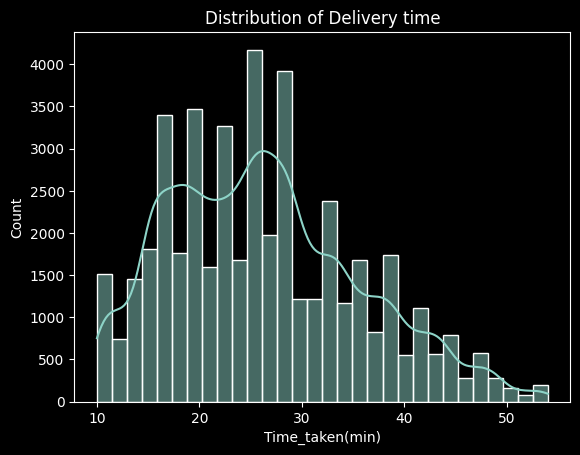

In [132]:
# TO chech the distribution of numerical column we use histogram:
sns.histplot(data['Time_taken(min)'],bins = 30,kde = True) # bins - how many bars, kde - density curve
plt.title("Distribution of Delivery time")
plt.show()

In [133]:
# lets chaeck each and every feature, 1st lets go with categorical columns:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [134]:
data['Road_traffic_density'].value_counts()

Road_traffic_density
Low       16078
Jam       14143
Medium    10947
High       4425
Name: count, dtype: int64

 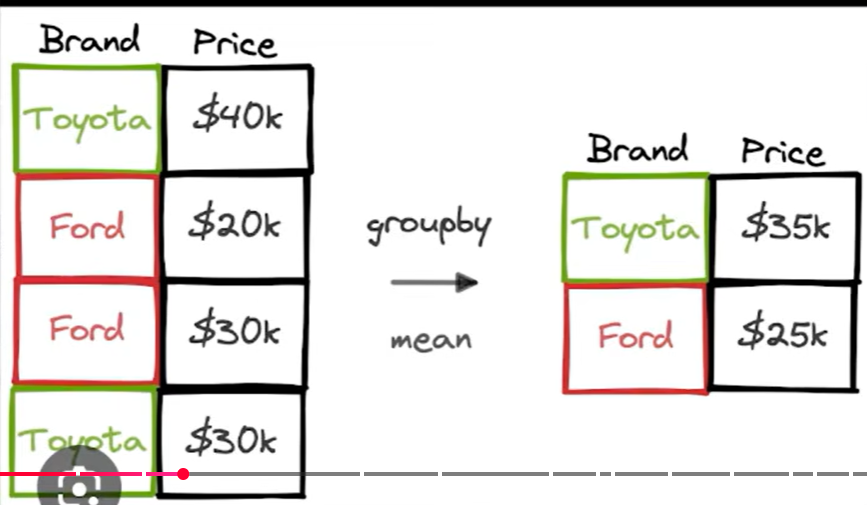

here we use groupby() function - This will group same category and perfrom aggeration function like add,mean,min,mix,etc.
corresponding to 'high' values the mean,median and std of 'time taken' column is used 

#### Letc check for categorical Varibles that affect the target varibles

In [135]:
# lets connect Road_traffic_density with the delivery time:
# here we use groupby() function - This will group same category and perfrom aggeration function like add,mean,min,mix,etc. 

data.groupby('Road_traffic_density')['Time_taken(min)'].agg(['count','mean','median','std'])
# corresponding to 'high' values the mean,median and std of 'time taken' column is used 

,count,mean,median,std
Road_traffic_density,,,,
High,4425,27.240000,27.0,8.396012
Jam,14143,31.176624,31.0,9.940904
Low,16078,21.464175,21.0,6.988438
Medium,10947,26.699644,27.0,8.560179


In [136]:
data['Weatherconditions'].value_counts()

Weatherconditions
Fog           8270
Stormy        7586
Cloudy        7536
Sandstorms    7495
Windy         7422
Sunny         7284
Name: count, dtype: int64

In [137]:
# here we are checking that: Does oes road time taken to deliver is affected by Watherconditions
data.groupby('Weatherconditions')['Time_taken(min)'].agg(['count','mean','median','std'])
# - means that if the whether is clear the delivery time is appraently less

,count,mean,median,std
Weatherconditions,,,,
Cloudy,7536,28.917330,28.0,10.084352
Fog,8270,28.739541,28.0,10.100816
Sandstorms,7495,25.875517,26.0,8.618434
Stormy,7586,25.870815,26.0,8.473273
Sunny,7284,21.856947,20.0,8.327210
Windy,7422,26.118836,26.0,8.615702


In [138]:
data['Festival'].value_counts()

Festival
No     44697
Yes      896
Name: count, dtype: int64

In [139]:
# here we are checking that: Does time taken to deliver is affected by Festival
data.groupby('Festival')['Time_taken(min)'].agg(['count','mean','median','std'])
# - means that if there's any festive season.. the delivery time jumps from 25min to 45min.. this is the larger difference we have noticed here 

,count,mean,median,std
Festival,,,,
No,44697,25.909256,25.0,9.052291
Yes,896,45.517857,45.0,4.001915


In [140]:
data['City'].value_counts()

City
Metropolitian    35293
Urban            10136
Semi-Urban         164
Name: count, dtype: int64

In [141]:
data.groupby("City")["Time_taken(min)"].agg(['count','mean','median','std'])
# here we can see that semi-urban cities takes more time than Metropolitian and Urban 
# whereas urban cities takes less time 

,count,mean,median,std
City,,,,
Metropolitian,35293,27.136486,26.0,9.205358
Semi-Urban,164,49.731707,49.0,2.693089
Urban,10136,22.984017,22.0,8.866011


In [142]:
data.groupby('Type_of_vehicle')["Time_taken(min)"].agg(['count','mean','median','std'])

# it seems like almist same only bicycle and motorcycle takes an extra time.

,count,mean,median,std
Type_of_vehicle,,,,
bicycle,68,26.426471,26.0,9.262855
electric_scooter,3814,24.470110,24.0,8.610859
motorcycle,26435,27.605674,26.0,9.647811
scooter,15276,24.480754,24.0,8.704238


In [143]:
data.groupby('Type_of_order')["Time_taken(min)"].agg(['count','mean','median','std'])

# this doesnt have much differnce - so this variable doesnt effect the target varibale.

,count,mean,median,std
Type_of_order,,,,
Buffet,11280,26.283511,26.0,9.411344
Drinks,11322,26.187953,25.0,9.298465
Meal,11458,26.419270,26.0,9.424849
Snack,11533,26.286309,26.0,9.399147


#### Now lets go for Numerical Varible(Features):

In [144]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [145]:
data['Delivery_person_Age'].describe()

count    45593.000000
mean        29.584739
std          5.696333
min         15.000000
25%         25.000000
50%         30.000000
75%         34.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

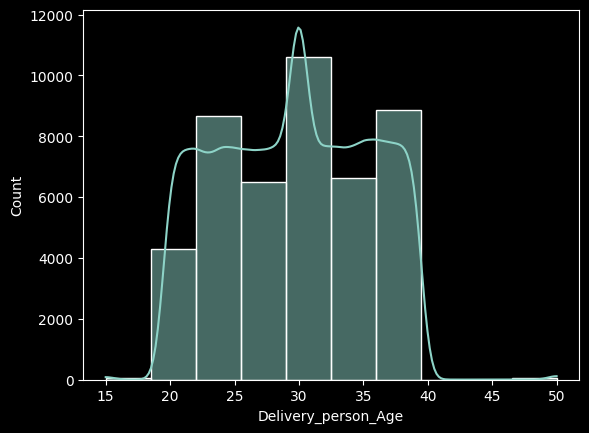

In [146]:
plt.style.use('dark_background')
sns.histplot(data['Delivery_person_Age'],bins = 10,kde = True)
plt.show()

# here we can see that some delivery persons's age is 50 

In [147]:
data[data['Delivery_person_Age']>40]['Delivery_person_Age'].shape

(53,)

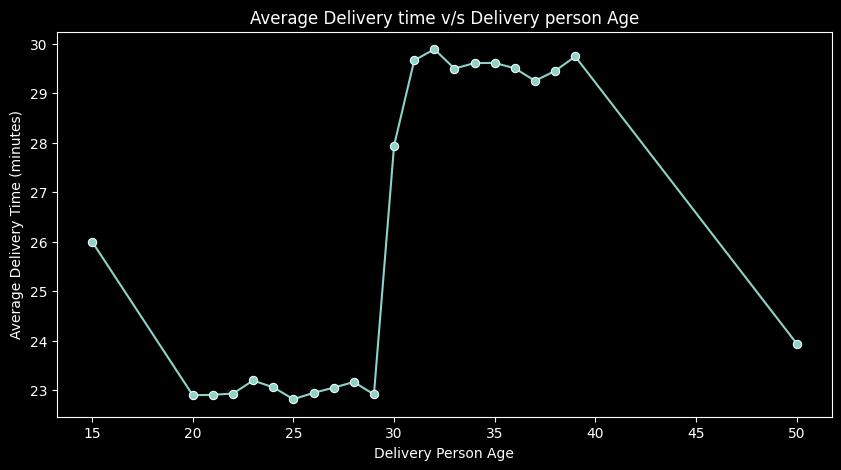

In [154]:
# Ling plot: to find the ration between the delivery person Age and Delivery Time (to chech if there's any relation between them)

plt.figure(figsize = (10,5))

sns.lineplot(
    data = data,
    x = "Delivery_person_Age",
    y = "Time_taken(min)",
    estimator = "mean",
    errorbar = None,
    marker = "o"
)

plt.title("Average Delivery time v/s Delivery person Age")
plt.xlabel("Delivery Person Age")
plt.ylabel("Average Delivery Time (minutes)")

plt.show()

# from The below figure we can make the observations that if the delivery person Age is from 20-35 The delivery Time is less whereas if the Age>30. 
# The delivery takes more time 
# Buisness Insight: The delivery person should be young.. so that delivery reaches faster 

In [155]:
data["Delivery_person_Ratings"].describe()

count    45593.000000
mean         4.635389
std          0.324828
min          1.000000
25%          4.600000
50%          4.700000
75%          4.800000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

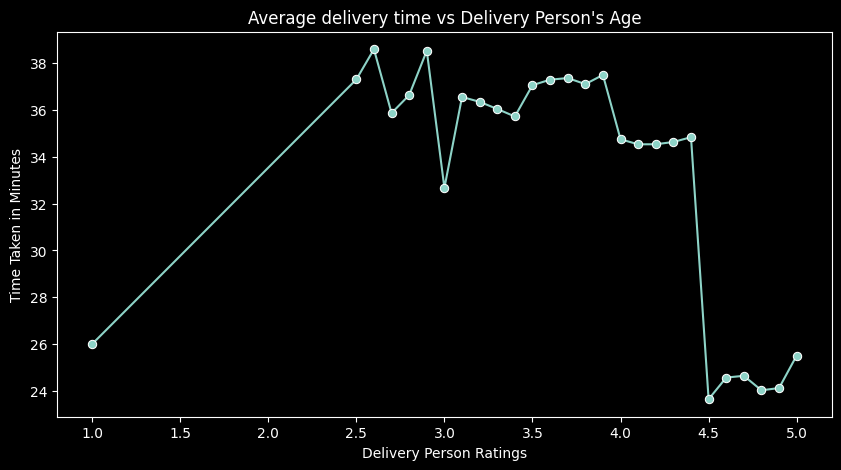

In [157]:
plt.figure(figsize = (10,5))

sns.lineplot(
    data = data,
    x = "Delivery_person_Ratings",
    y = "Time_taken(min)",
    estimator = "mean",
    errorbar = None,
    marker = "o"
)

plt.title("Average delivery time vs Delivery Person's Age")
plt.xlabel("Delivery Person Ratings")
plt.ylabel("Time Taken in Minutes")

plt.show()

#### Corelatio Heatmap (numeric columns)
 - This is done because we need to find the corelation between each other varibles.
 - If it is highly correlated we cant use that for linear models

In [158]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  43862 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

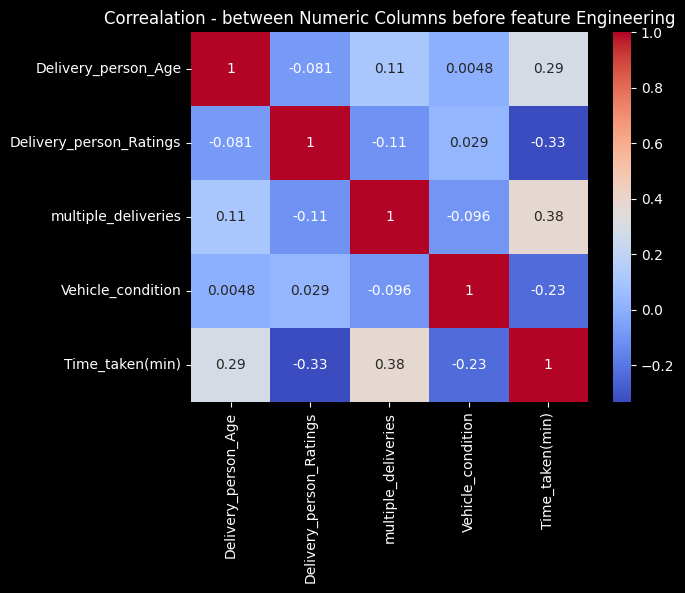

In [159]:
numeric_cols = ["Delivery_person_Age","Delivery_person_Ratings","multiple_deliveries","Vehicle_condition","Time_taken(min)"]
sns.heatmap(data[numeric_cols].corr(),annot = True,cmap = 'coolwarm')
plt.title("Correalation - between Numeric Columns before feature Engineering")

plt.show()